First 5 Rows:
                                               Quote           Author
0  “The world as we have created it is a process ...  Albert Einstein
1  “It is our choices, Harry, that show what we t...     J.K. Rowling
2  “There are only two ways to live your life. On...  Albert Einstein
3  “The person, be it gentleman or lady, who has ...      Jane Austen
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe

Dataset Shape:
(10, 2)

Column Names:
Index(['Quote', 'Author'], dtype='object')

Data Types:
Quote     object
Author    object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Quote   10 non-null     object
 1   Author  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None

Missing Values:
Quote     0
Author    0
dtype: int64


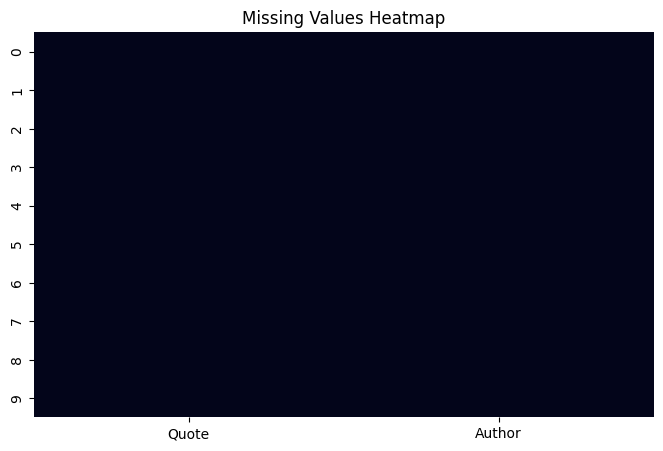


Statistical Summary:
                                                    Quote           Author
count                                                  10               10
unique                                                 10                8
top     “The world as we have created it is a process ...  Albert Einstein
freq                                                    1                3

Sample Questions:
1. Which category appears most frequently?
2. Are there missing values?
3. What patterns exist in the dataset?
4. Are there any unusual observations?

Duplicate Rows: 0

Data Quality Report
-------------------
Missing Values:
Quote     0
Author    0
dtype: int64

Duplicate Records:
0

Data Types:
Quote     object
Author    object
dtype: object

EDA Completed Successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("quotes_dataset.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

print("\nStatistical Summary:")
print(df.describe(include='all'))

print("\nSample Questions:")
print("1. Which category appears most frequently?")
print("2. Are there missing values?")
print("3. What patterns exist in the dataset?")
print("4. Are there any unusual observations?")


print("\nDuplicate Rows:", df.duplicated().sum())


num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


if len(num_cols) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_cols].corr(),
                annot=True,
                cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()


for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

from scipy.stats import ttest_ind

if len(num_cols) > 0:
    col = num_cols[0]

    median_value = df[col].median()

    group1 = df[df[col] <= median_value][col]
    group2 = df[df[col] > median_value][col]

    t_stat, p_value = ttest_ind(group1, group2)

    print("\nHypothesis Testing")
    print("T-statistic:", t_stat)
    print("P-value:", p_value)

    if p_value < 0.05:
        print("Significant Difference Found")
    else:
        print("No Significant Difference Found")


print("\nData Quality Report")
print("-------------------")
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nEDA Completed Successfully!")